In [1]:
import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path

##########################################################
# Initialize parameters  
##########################################################

# the original files Jaafar ran:
#filename = "/data/fromlabpix/warm/packet-warm_pedestal-2025_10_28_13_40_41_PDT.h5" # all 5 tiles in B70 cryo. Warm. No channels disabled. Sync pulses
#filename = "/data/fromlabpix/cold/packet-cold_pedestal_5tiles_vdda1p8_nom-2025_10_30_12_16_02_PDT.h5" # Cold. 5 tiles. No channels disabled. Sync pulses


#filename = "../data/packet-2025_11_12_14_35_06_PST.h5"
filename = "../data/packet-warm_4tiles_tally_2025_11_19_09_23_21_PST.h5"
#filename = '../data/packet-2025_11_19_11_31_34_PST.h5' # disabled link [29,30] in tile 2 (with invalid parity)
#filename = '../data/packet-2025_11_19_12_44_02_PST.h5' # disabled links [29,30] and [30-40] in tile 2
#filename = '../data/packet-2025_11_19_13_37_10_PST.h5' # disabled hot channels and links [29,30], [30-40] in tile 2

#filename = "../data/packet-warm_5tiles_hotchan3_2025_11_05_15_26_23_PST.h5"
#filename = "../data/packet-warm_4tiles_tally_2025_11_11_14_40_41_PST.h5"
#filename = "../data/packet-warm_4tiles_leakage_11_11_15_41_13_PST.h5"


asic_dir = "../asic_configs/asic_configs_2025_11_19_13_07_PST/"
#asic_dir = "../asic_configs/asic_configs_2025_11_12_14_28_PST/"
#asic_dir = '../asic_configs/asic_configs_warm_tally_2025_11_11_14_02_PST/'
#asic_dir = '../asic_configs/asic_configs_warm_4tiles_leakage_2025_11_11_15_33_PST/'

# the tile # is listed on the tile just above the flat data cable connection to the pacman
#tiles = [1,2,3,4,5]
tiles = [1,2,3,4]
#tiles = [1]
chip_serial_number_list = ['', '4k02056', '4k02533', '4k03591', '4k01892', '4k03537']

# if there are misnumbered chips you can see if they came from a chip that has low packet counts using
# the following pairing. List the legitimate chip_id first in this pair
problem_chip_pair = [[],[161,225],[],[],[],[]] # put the chip_id you believe is valid first in this pair 

# if you want to see the channel count graph on a given chip assign its chip # here
problem_chip = None

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = False

# the following values are just being initialized to zero
nenabled_chips = 0
ig = 1 #this script can only run 1 io_group (and 1 tile) at a time
files = []
ndisabled_channels = [0 for chp in range(256)]
network = {}
first_tile = True

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
# create an array of file names from the directory passed to this function
def get_files(directory):

    global nenabled_chips
    
    asic_config_files = []  # the set of files in the given directory
    f_number = 0
    found_files = False

    with os.scandir(directory) as entries:

        # order the directory files by names
        file_entries = sorted(entries, key=lambda entry: entry.name)
        file_items = [entry.name for entry in file_entries]
        
        f_number = len(file_items) # number of files in the directory
        nenabled_chips = f_number

        for i in range(1,f_number):
            filename = directory + file_items[i]
            asic_config_files.append(filename)
            found_files = True

        if found_files == False:
            print(f'\n##### Did not find files in directory {directory} #####\n')

    print(f'\t{nenabled_chips} asic_config files were read')
    
    return asic_config_files

In [3]:
# given a raw data file, this code obtains the dictionary "network" which records the 
# chips in each io_channel hydra network as it was configured for that file
def extract_network(name):

    global network

    for file in os.listdir(name+'/hydra_network'):
        with open(name+'/hydra_network/'+file) as f: d=json.load(f)
    
        for io_group in d['network'].keys():
            if io_group in ['miso_us_uart_map', 'miso_ds_uart_map', 'mosi_uart_map']: continue
            if not int(io_group) in network.keys(): network[int(io_group)]={}
            for io_channel in d['network'][io_group].keys():
                if not int(io_channel) in network[int(io_group)].keys(): network[int(io_group)][int(io_channel)] = []
                for i in range(len(d['network'][io_group][io_channel]['nodes'])-1):
                    network[int(io_group)][int(io_channel)].append(d['network'][io_group][io_channel]['nodes'][i+1]['chip_id'])

    return

In [4]:
# from the tar file information get the dictionary "configs" that contains configuration 
# information stored at the beginning of each 3-minute data file. Configuration Keys: 
# dict_keys(['threshold_global', 'ref_current_trim', 'vref_dac', 'vcm_dac', 'adc_hold_delay', 'chip_id', 
# 'enable_piso_upstream', 'enable_piso_downstream', 'enable_posi', 'enable_periodic_reset', 'enable_rolling_periodic_reset', 
# 'channel_mask', 'periodic_reset_cycles', 'tx_slices0', 'tx_slices1', 'tx_slices2', 'tx_slices3', 'i_tx_diff0', 
# 'i_tx_diff1', 'i_tx_diff2', 'i_tx_diff3', 'r_term0', 'r_term1', 'r_term2', 'r_term3', 'csa_enable', 'pixel_trim_dac'])

def get_configs(name):
    configs = {}
    
    for file in os.listdir(name+'/asic_configs'):
        with open(name+'/asic_configs/'+file) as f: d=json.load(f)
        configs[d['meta']['CHIP_KEY']] = { reg : d[reg] for reg in d.keys() if not reg=='meta' }
        
    return configs

In [5]:
# each 3-minute raw data file has a set of keys: ['_header', 'configs', 'daq_configs', 
# 'messages', 'packets']. A tar file (stored in key = "daq_configs") contains 
# configuration settings for each chip in the charge read-out system at the beginning
# of the file's 10-minute time period. It also contains configuration details. 
# This code unpacks the tar file
def extract_config(file):
    
    with h5py.File(file) as h5f:   
        #print(f'\tKeys in datafile {file}:\n{h5f.keys()}')
        buf = io.BytesIO(np.array(h5f['daq_configs']).data) # the tar file is stored under the key 'daq_configs'

    extract=True
    with tarfile.open(fileobj=buf) as tarf:
        name = tarf.getmembers()[0].name 
        if Path(name).exists(): # if the tar file has already been extracted there's no need to do it again
            extract=False
        if extract: tarf.extractall() 
    return name

In [6]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20]
                     ]
    
    return io_ch_per_tile[tile]


In [7]:
def get_data(filename, tile, ig):
    
    global data_pkts, npkts_mode, npkts_mode_chan, ndisabled_channels
    global chip_serial_number, first_tile
    
    data_chips, ndata_by_chip_list, ndata_by_channel_list, npkts = [], [], [], 0
    ndata_by_chip    = [0 for chip in range(256)]
    ndata_by_channel = [[0 for chan in range(64)] for chip in range(256)]
    
    invalid_chips, ninvalid, ninvalid_by_chip = [], 0, []
    full_chips   , nfull   , nfull_by_chip    = [], 0, []
    bad_std, bad_mean = 0, 0
    bad_std_list, bad_mean_list = [], []
    mean_adc_list, std_adc_list = [], []
    unique_chips  = []
    nsyncs = []
    misnumbered_chips = False
    wrong_ioch_chip = False
    debug_count = 0

    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    unixtime = f['packets'][:]['timestamp'][f['packets']
                                            [:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]

    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # print out run statistics for the file
    if first_tile:
        npkts         = len(data_pkts) 
        print(f"\t{npkts} data packets for tile {tile} arriving at an average rate of {npkts/livetime:.0f} pkts/s over {livetime}s of data taking") 
        print(f"\tIO_channels in file: \n\t{[int(x) for x in unique_io_channels]}")
        first_tile = False

    # get a list of the io_channels that could be enabled for a given tile, and then determine which
    # ones were enabled
    io_channel_ids = get_io_channels(tile)
    enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
    
    print(f"\n\n############################ Checking Tile {tile} ###################################")
    print(f'Run Statistics for Tile {tile}:')    
    print(f'\tio_channels enabled for tile {tile}: {enabled_io_channels}')
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]

    # identify chips on this tile with data packets
    unique_chips = list(dict.fromkeys(data_pkts['chip_id'][:]))    
    
    npkts = len(data_pkts) 

    if npkts ==0: 
        print(f'There are no data packets for tile {tile}')        
        return
    
#########################################################
# identify misnumbered chips, out of range adc datawords
##########################################################
    
    data_chips = data_pkts['chip_id'][:]

    unique_chips = list(dict.fromkeys(data_chips))

    print(f'\t{len(unique_chips)} chips were recorded from Tile {tile}')    
    
    for chip in unique_chips:

        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        chip_ioch  = chip_pkts['io_channel'][:]
        chip_chans = chip_pkts['channel_id'][:]
        chip_adc   = chip_pkts['dataword'][:]

        unique_iochs = list(dict.fromkeys(chip_ioch))
        
        # create list used to determine mode of # pkts per chip
        ndata_by_chip[chip] = len(chip_pkts)
        ndata_by_chip_list.append(ndata_by_chip[chip])
        
        mode_adc_chip = mode(chip_adc)

        unique_channels = list(dict.fromkeys(chip_chans))
        
        # create list used to determine mode of # pkts per channel, and check for adc means outside of range mode +/- 50
        for chan in unique_channels:
            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]
            chan_adc  = chan_pkts['dataword']
            
            # remove zero datawords
            non_zero_chan_adc = chan_adc[chan_adc != 0]

            # count the # of packets by channel
            ndata_by_channel[chip][chan] = len(chan_pkts)
            if ndata_by_channel[chip][chan] > 0:
    
                ndata_by_channel_list.append(ndata_by_channel[chip][chan])

            # calculate acd mean and stdev and check that they are in the acceptable range
            if len(non_zero_chan_adc) > 1:
               
                mean_adc = mean(non_zero_chan_adc.tolist())
                mean_adc_list.append(mean_adc)
                if mean_adc > mode_adc_chip + 50 or mean_adc < mode_adc_chip - 50:
                    bad_mean_list.append(str(f"{chip}-{chan}"))
                    bad_mean +=1

                std_adc = stdev(non_zero_chan_adc.tolist())
                std_adc_list.append(std_adc)
                if std_adc > 2 or std_adc < 0.01:
                    bad_std +=1
                    bad_std_list.append(str(f"{chip}-{chan}"))

            elif verbose:
                print(f"channel {chip}-{chan} had no packets")
                    
        # look for chips in the wrong io_channel        
        for ioch in unique_iochs:
            if chip not in network[ig][ioch]:
                print(f'\nChip {chip} on Tile {tile} should not be in IO_channel {ioch}. It is probably misnumbered.')
                wrong_ioch_chip = True
            else:
                wrong_ioch_chip = False
        
        # look for misnumbered chips
        if chip not in range(11,171) or wrong_ioch_chip:

            misnumbered_chips = True

            unique_io_channels = list(dict.fromkeys(chip_pkts['io_channel'][:]))

            for ioch in unique_io_channels:

                valid_percent   = 100 * chip_pkts['valid_parity'][:].tolist().count(1) / ndata_by_chip[chip]
                invalid_percent = 100 * chip_pkts['valid_parity'][:].tolist().count(0) / ndata_by_chip[chip]
                
                print(f'Misnumbered Chip {chip} from IO_channel {ioch} on Tile {tile} has {ndata_by_chip[chip]} data packets of which, {valid_percent:.1f}% have valid parity and {invalid_percent:.1f} have invalid parity\n')

            if verbose:
                print(f'1st packet from misnumbered chip:') 
                for name in range(len(chip_pkts[0])):                
                    print(f'\n\t{chip_pkts.dtype.names[name]} = {chip_pkts[0][name]}')    
                
    npkts_mode = mode(ndata_by_chip_list)
    npkts_mode_chan = mode(ndata_by_channel_list)

    mode_mean_tile = mode(mean_adc_list)
    mean_stdev_tile = mean(std_adc_list)
        
    if problem_chip_pair[tile] != []:
        combine_chips(problem_chip_pair[tile])
    
#################################
# identify invalid chips
#################################

    print(f'\n\n>>>>> Looking for Invalid Parity')

    invalid_mask  = data_pkts['valid_parity'] == 0
    invalid_pkts  = data_pkts[invalid_mask]
    ninvalid      = len(invalid_pkts)
    
    print(f"\t# of invalid packets = {ninvalid}\t or {100 * ninvalid/npkts:.1f}% of all data packets on Tile {tile}")
    
    # histogram any chips with invalid packets
    if ninvalid > 0:
    
        invalid_chips = invalid_pkts['chip_id'][:]
        
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(invalid_chips, bins=256)
        ax.set_title(f'Invalid Parity Packet Count per Chip on Tile {tile}\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
        ax.set_xlabel(f'Chip ID')
        ax.set_yscale('log')
        ax.set_ylabel(f'Invalid Packet Count')
        plt.show 

        unique_chips = list(dict.fromkeys(invalid_chips))
        print(f'\nCount of Invalid Parity packets by chip on Tile {tile}:')

        for chip in unique_chips:
            ninvalid_by_chip = invalid_chips.tolist().count(chip)
            print(f'\tTile {tile} Chip {chip}: {ninvalid_by_chip} \tor {100*ninvalid_by_chip/ndata_by_chip[chip]:.2f}% of the {ndata_by_chip[chip]} packets from this chip')

            chip_mask = data_pkts['chip_id'] == chip
            chip_pkts = data_pkts[chip_mask]
    
            chip_valid_parity  = chip_pkts['valid_parity'][:]

            last_pkt = 0
            
            for pkt in range(len(chip_valid_parity)):
                if chip_valid_parity[pkt] == 0:
                    print(f'\nChip {chip}: Invalid parity on packet {pkt} out of {len(chip_valid_parity)} total packets')
                    if last_pkt > 0:
                        print(f'\t distance between invalid packets = {pkt-last_pkt}')
                    last_pkt = pkt
    
    return 

In [8]:
def combine_chips(chip_pair):

    global data_pkts, npkts_mode, npkts_mode_chan, ndisabled_channels

    combined_channels = []

    # combine the data packets from 2 chips to see if it looks like they came from the same chip
    for chip in chip_pair:
    
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]
        
        # combine the chanel ids into one list
        channels   = chip_pkts['channel_id'][:]
        combined_channels.extend(channels)

    # count how many packet you expected in the combined chip
    nchannels = 64

    # if both chips in the pair have legitimate chip #s then you should expect 2x the number of packets 
    if chip_pair[0] in range(11,171) and chip_pair[1] in range(11,171):
        npkts_expected = 2 * nchannels * npkts_mode_chan
        npkts_hline    = 2 * npkts_mode_chan
    
    else:
        npkts_expected = nchannels * npkts_mode_chan
        npkts_hline    = npkts_mode_chan
        
    npkts_combined = len(combined_channels)

    # look for chips with unusually high or low data counts. Each channel may have 1 extra (or 1 fewer) packets than the mode
    print(f'\nAdding packets from chips {chip_pair[0]} and {chip_pair[1]} produces {npkts_combined} pkts or {100 * npkts_combined/npkts_expected:.0f}% of expected')
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.set_title(f'Packet Count per Channel from Combining Chips {chip_pair[0]} and {chip_pair[1]}\nExpected Chan Pkt Count {npkts_mode_chan}\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    ax.hist(combined_channels, bins = 64)
    ax.set_xlabel("Channel ID")
    ax.set_ylabel("# Data Packets")
    ax.set_xlim(0,63)
    plt.show    

    return

Run Statistics for Data File ../data/packet-warm_4tiles_tally_2025_11_19_09_23_21_PST.h5:
	641 asic_config files were read
	7406762 data packets for tile 1 arriving at an average rate of 63851 pkts/s over 116s of data taking
	IO_channels in file: 
	[1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15]


############################ Checking Tile 1 ###################################
Run Statistics for Tile 1:
	io_channels enabled for tile 1: [1, 2, 3]
	161 chips were recorded from Tile 1

Chip 225 on Tile 1 should not be in IO_channel 1. It is probably misnumbered.
Misnumbered Chip 225 from IO_channel 1 on Tile 1 has 6044 data packets of which, 100.0% have valid parity and 0.0 have invalid parity


Adding packets from chips 161 and 225 produces 11574 pkts or 100% of expected


>>>>> Looking for Invalid Parity
	# of invalid packets = 0	 or 0.0% of all data packets on Tile 1


############################ Checking Tile 2 ###################################
Run Statistics for Tile 2:
	io_channels 

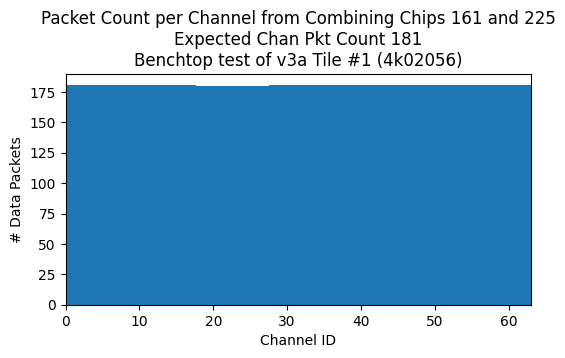

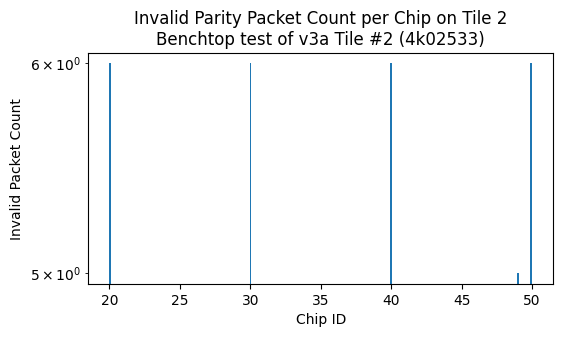

In [9]:
####################
# main
####################

print(f'Run Statistics for Data File {filename}:')

# get the hydra network configuration for each io_channel for the first file
config_dir = extract_config(filename)

# extract the dictionary "network" which stores information about the hydra network configuration
extract_network(config_dir)

# create file list of asic_config json files
files = get_files(asic_dir)

# get packets from pedestal run data file and check for various attributes
for tile in tiles:
    chip_serial_number = chip_serial_number_list[tile]
    get_data(filename, tile, ig)
